# Dataset plots

Visualization and threshold tuning for eye gesture event detection.

In [6]:
from pathlib import Path

from src.analyze import analyze_file
from src.blink_signal import has_blink_columns
from src.detection_config import DetectionConfig
from src.gaze_signal import has_gaze_columns
from src.io_utils import collect_csv_files
from src import plots


DATA_DIR = Path("data")
cfg = DetectionConfig()
files = collect_csv_files(DATA_DIR)
files[:5], len(files)

([PosixPath('data/BlinkData_20260729_144613_10s.csv'),
  PosixPath('data/BlinkData_20260729_144629_20s.csv'),
  PosixPath('data/BlinkData_20260729_144654_30s.csv'),
  PosixPath('data/CombinedGestureData_20260729_144740_combined.csv'),
  PosixPath('data/FixationData_20260729_144314_10s.csv')],
 10)

## Threshold adjustments

In [7]:
cfg = DetectionConfig(
    fixation_speed_threshold_deg_s=30.0,
    saccade_speed_threshold_deg_s=120.0,
    blink_threshold=0.60,
)

In [8]:
sample_path = files[0]
df, events = analyze_file(sample_path, cfg)
sample_path.name, events.head()

('BlinkData_20260729_144613_10s.csv',
                          source_file      phase gesture start_time_s  \
 0  BlinkData_20260729_144613_10s.csv  recording   blink        2.413   
 1  BlinkData_20260729_144613_10s.csv  recording   blink        3.912   
 2  BlinkData_20260729_144613_10s.csv  recording   blink        5.331   
 3  BlinkData_20260729_144613_10s.csv  recording   blink        6.858   
 4  BlinkData_20260729_144613_10s.csv  recording   blink        8.359   
 
   end_time_s duration_ms peak_value sample_count  
 0      2.572       159.0    0.89043           14  
 1      4.099       187.0   0.895995           16  
 2      5.405        74.0    0.88225            7  
 3       6.93        72.0   0.884805            7  
 4       8.53       171.0    0.99455           15  )

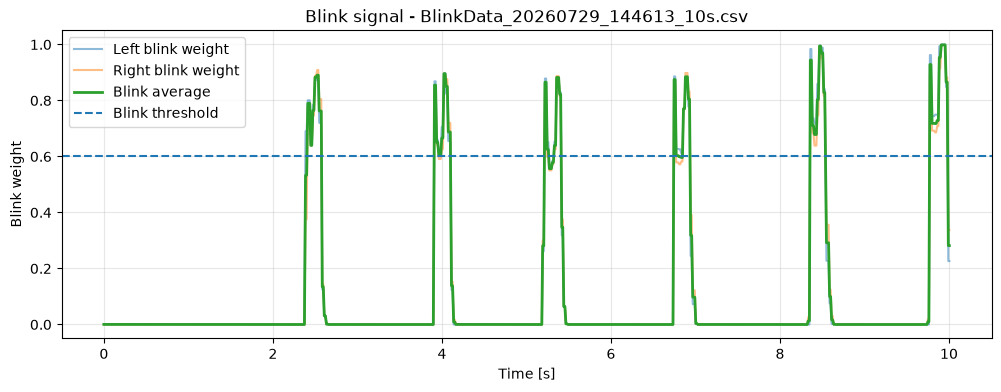

In [9]:
def plot_recording(df, cfg):
    if has_gaze_columns(df):
        plots.plot_gaze_speed(df, cfg)
        plots.plot_smoothed_gaze_speed(df, cfg)
    if has_blink_columns(df):
        plots.plot_blink_signal(df, cfg)


plot_recording(df, cfg)

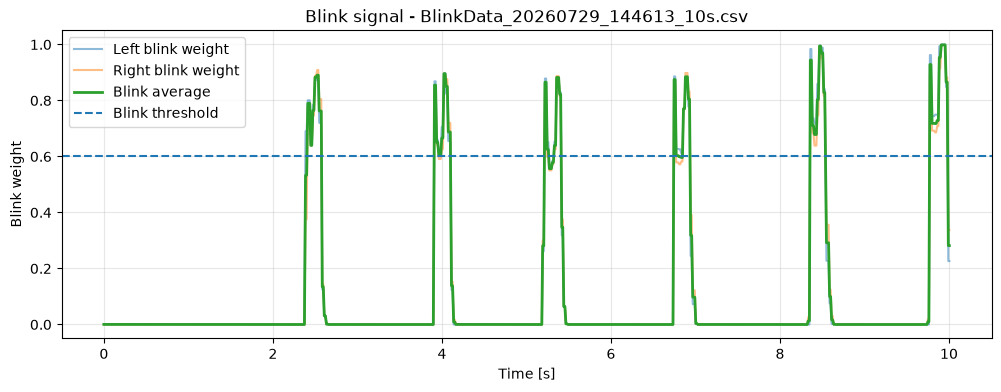

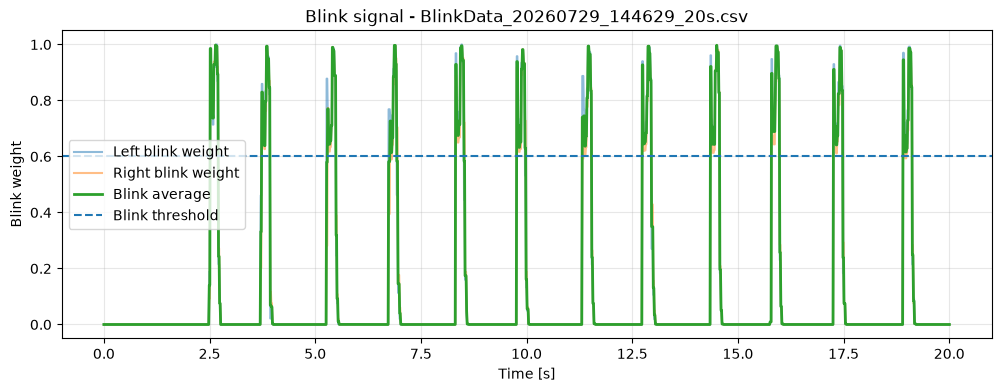

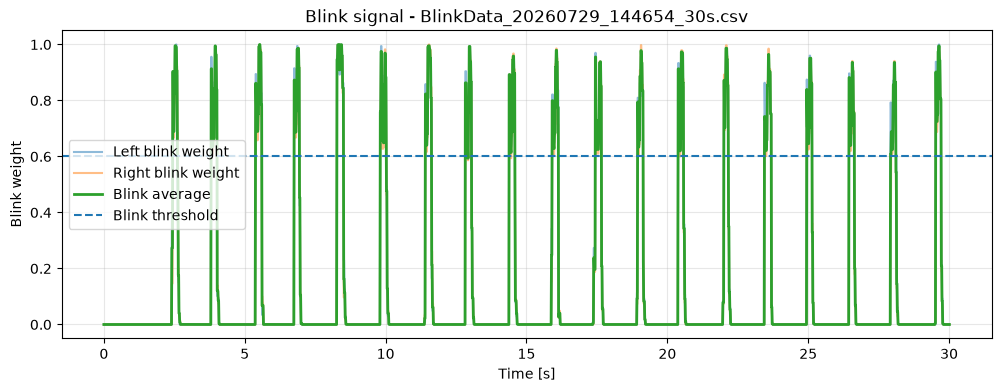

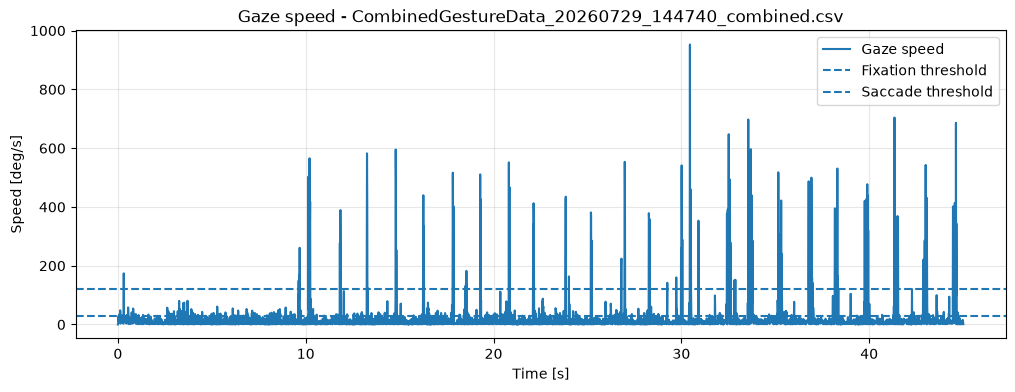

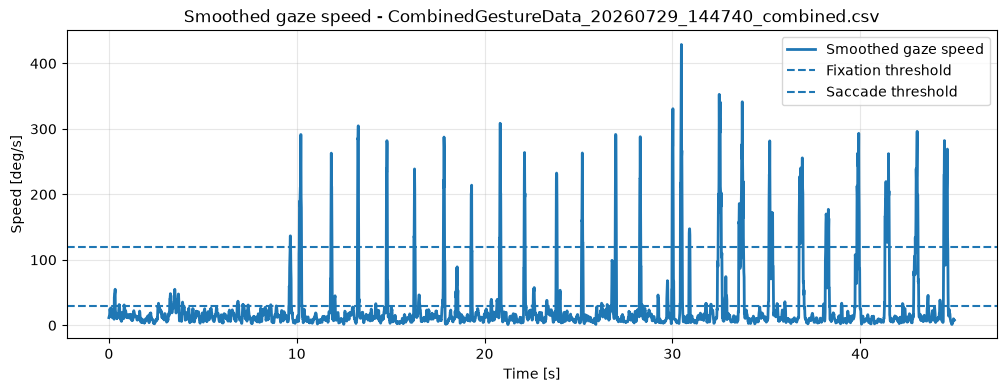

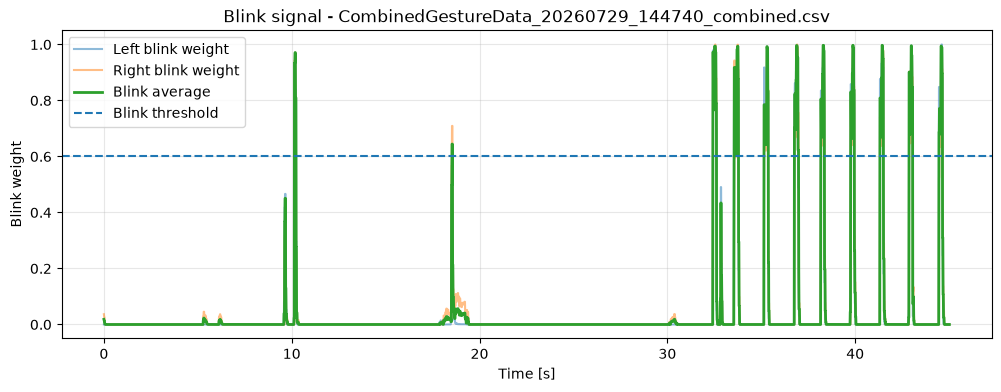

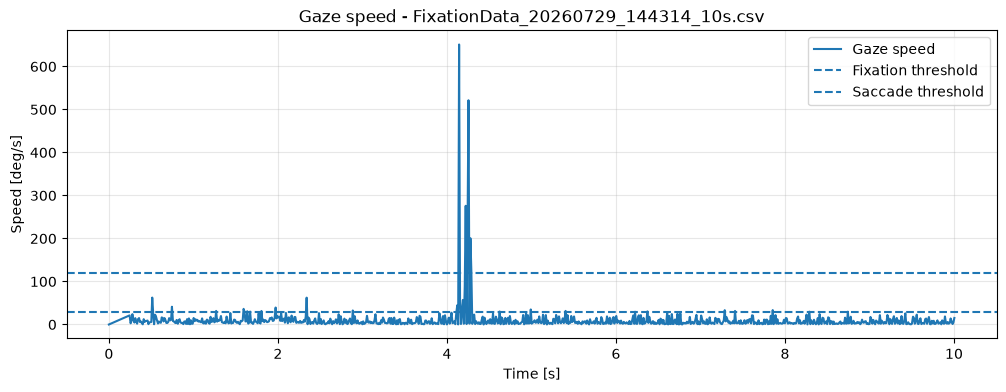

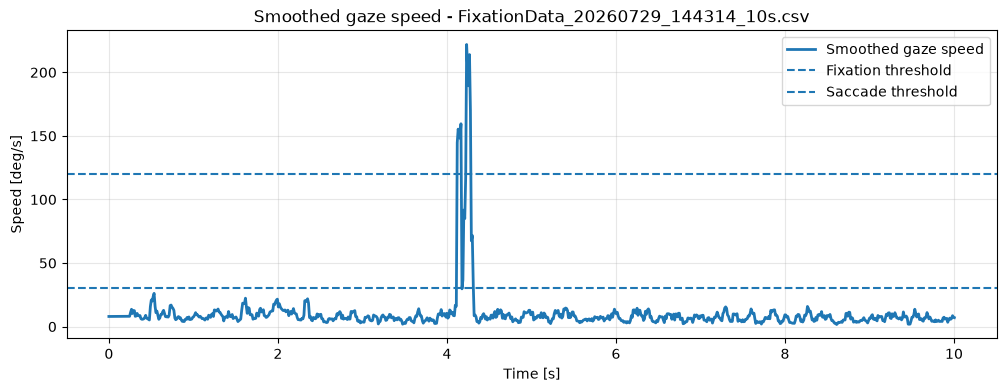

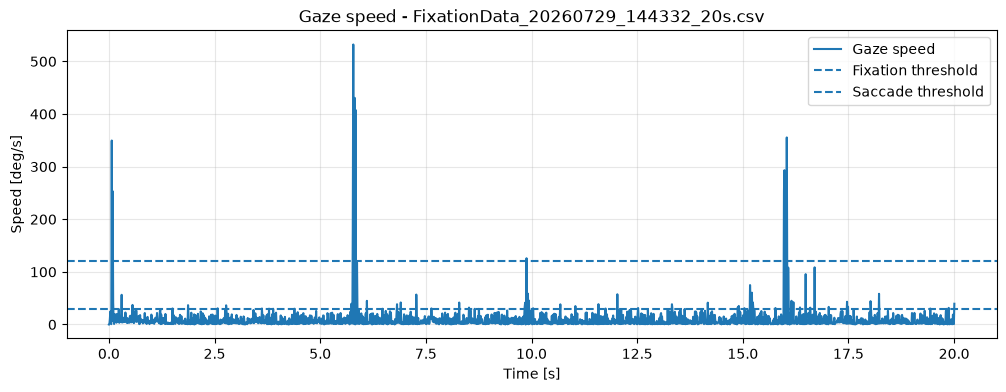

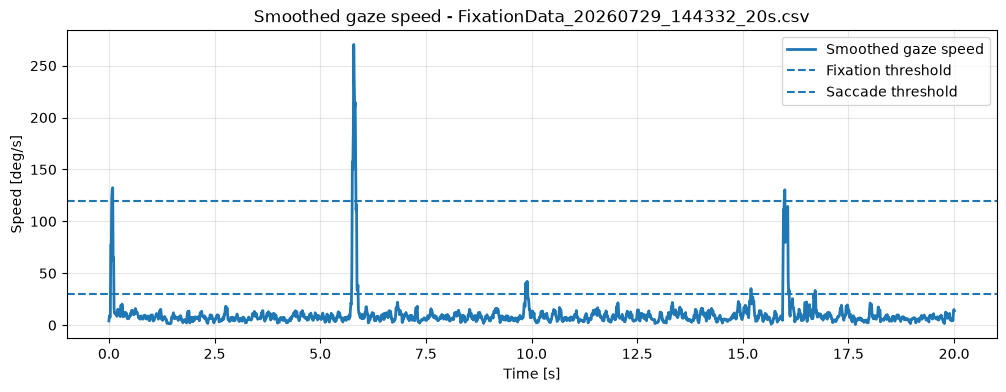

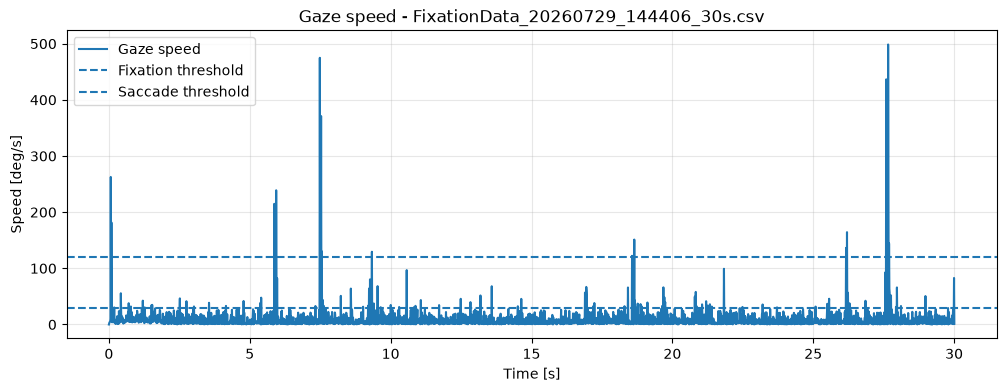

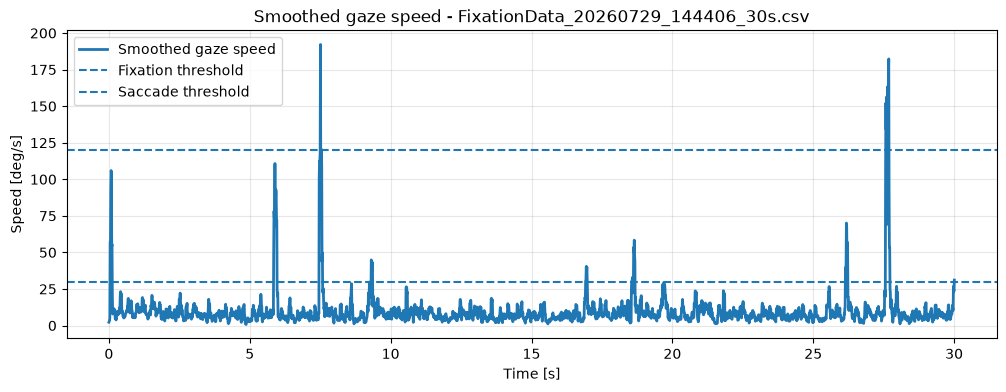

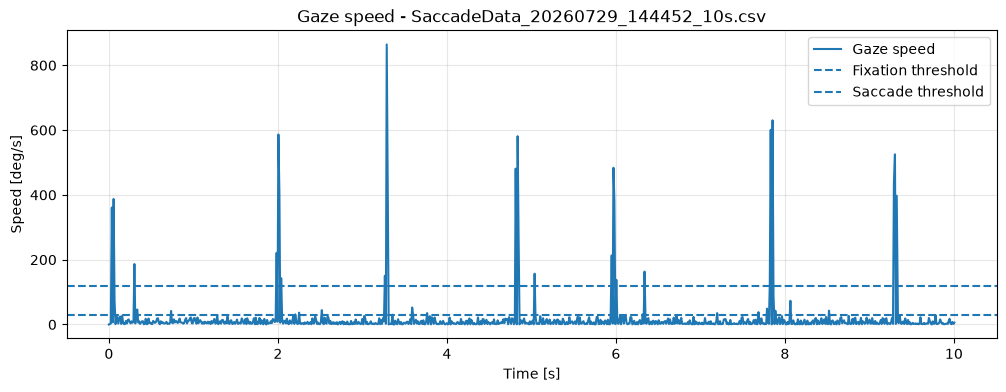

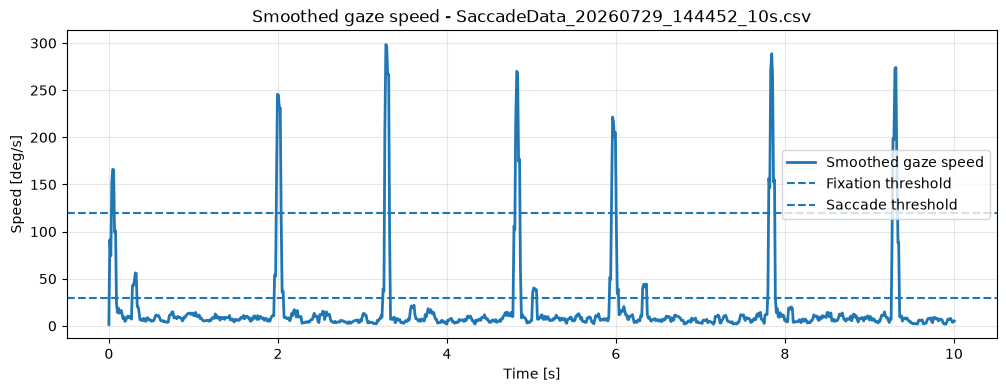

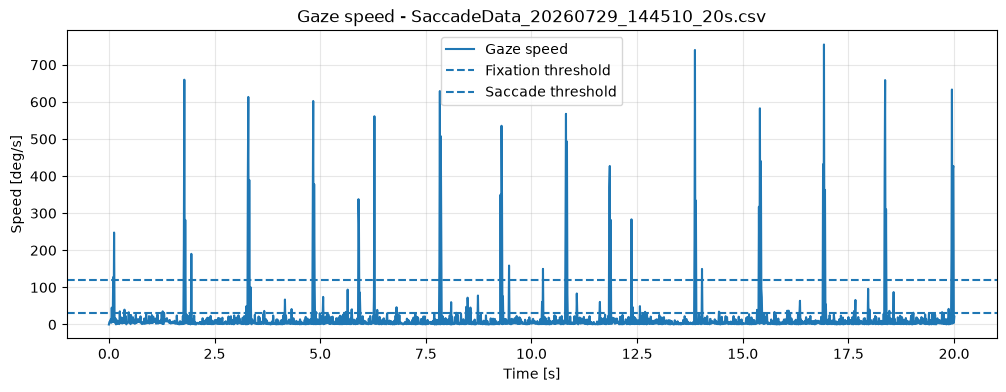

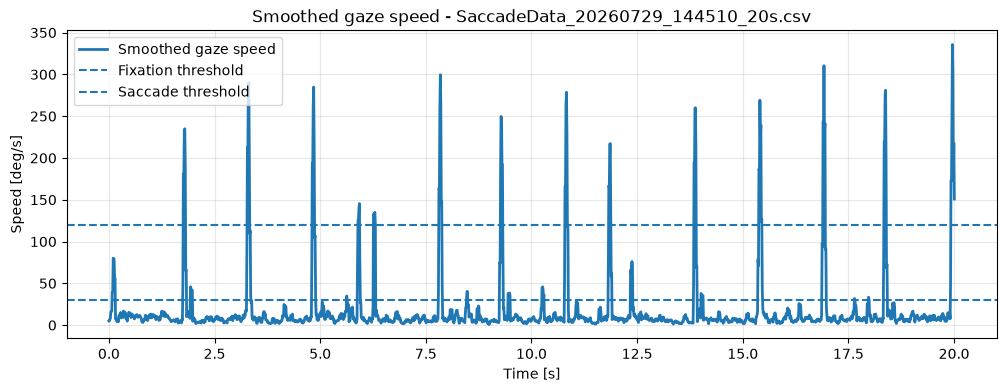

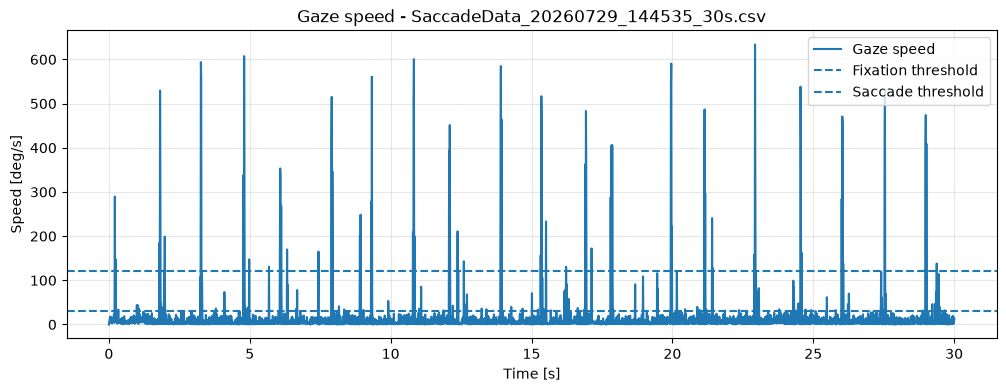

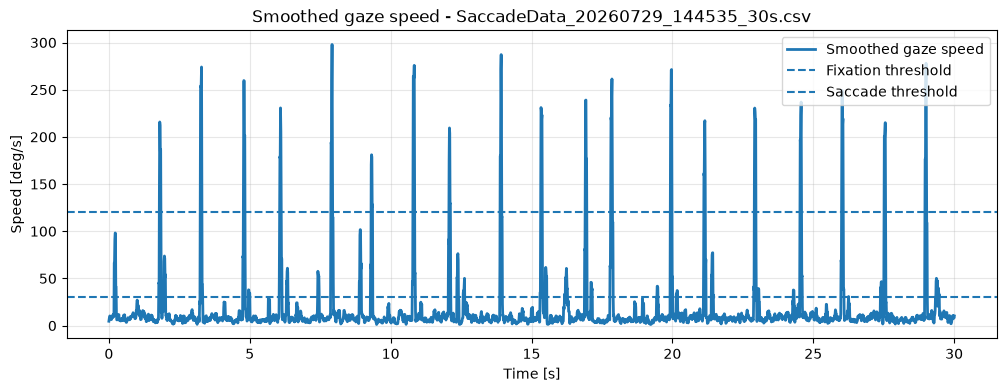

In [10]:
for path in files[1:]:
    df, _ = analyze_file(path, cfg)
    plot_recording(df, cfg)